In [1]:
from google.colab import ai

ai.list_models()

['google/gemini-2.5-flash', 'google/gemini-2.5-flash-lite']

In [2]:
from google.colab import ai
response = ai.generate_text("Explain quantum computing in simple terms.")

Available models:
['google/gemini-2.5-flash', 'google/gemini-2.5-flash-lite']

Running quick test...
Test response:
9 1 8 3

RUNNING MODEL: google/gemini-2.5-flash

--------------------------------
Condition: forward
--------------------------------


google/gemini-2.5-flash | forward:   0%|          | 0/5 [00:00<?, ?it/s]

Completed 25/100
Completed 50/100

--------------------------------
Condition: backward
--------------------------------


google/gemini-2.5-flash | backward:   0%|          | 0/5 [00:00<?, ?it/s]

Completed 75/100
Completed 100/100

Experiment finished.
                     model condition  sequence_length  trial  \
0  google/gemini-2.5-flash   forward                2      0   
1  google/gemini-2.5-flash   forward                2      1   
2  google/gemini-2.5-flash   forward                2      2   
3  google/gemini-2.5-flash   forward                2      3   
4  google/gemini-2.5-flash   forward                2      4   

  presented_sequence target_sequence raw_response predicted_sequence  \
0                 71              71          7 1                 71   
1                 01              01          0 1                 01   
2                 90              90          9 0                 90   
3                 11              11          1 1                 11   
4                 53              53          5 3                 53   

   prediction_length  exact_match  item_accuracy  
0                  2            1            1.0  
1                  2   

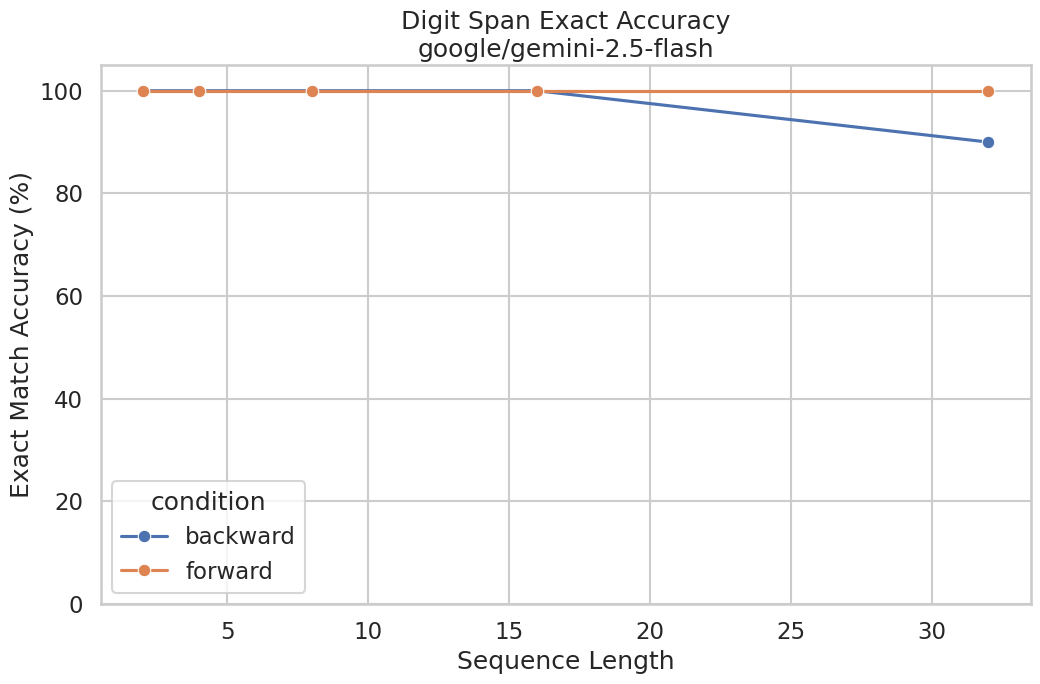

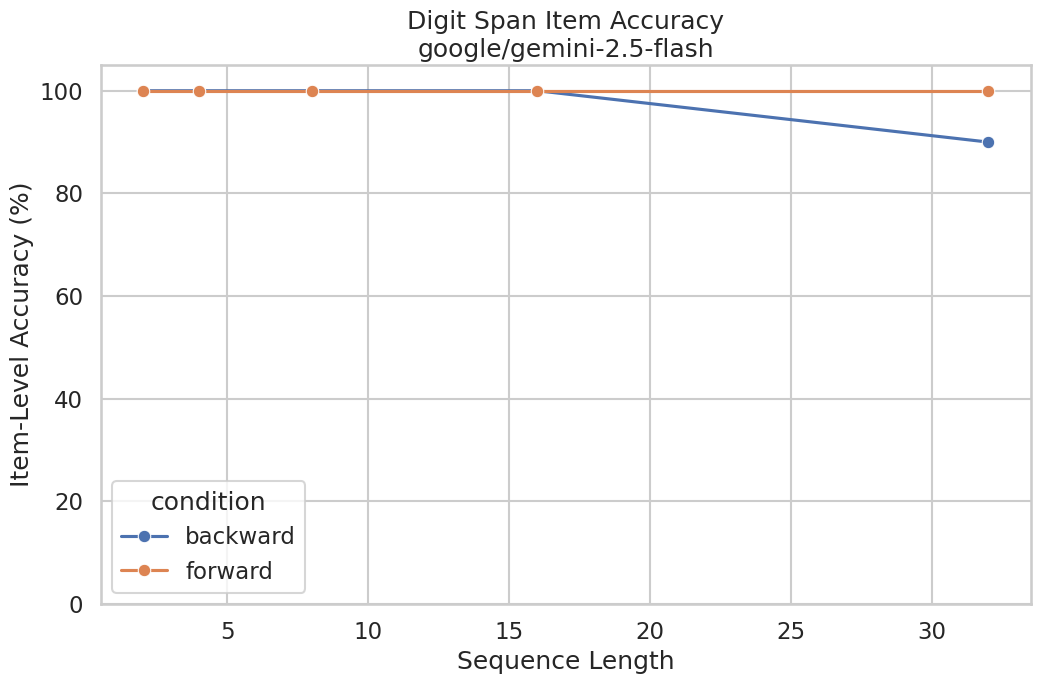

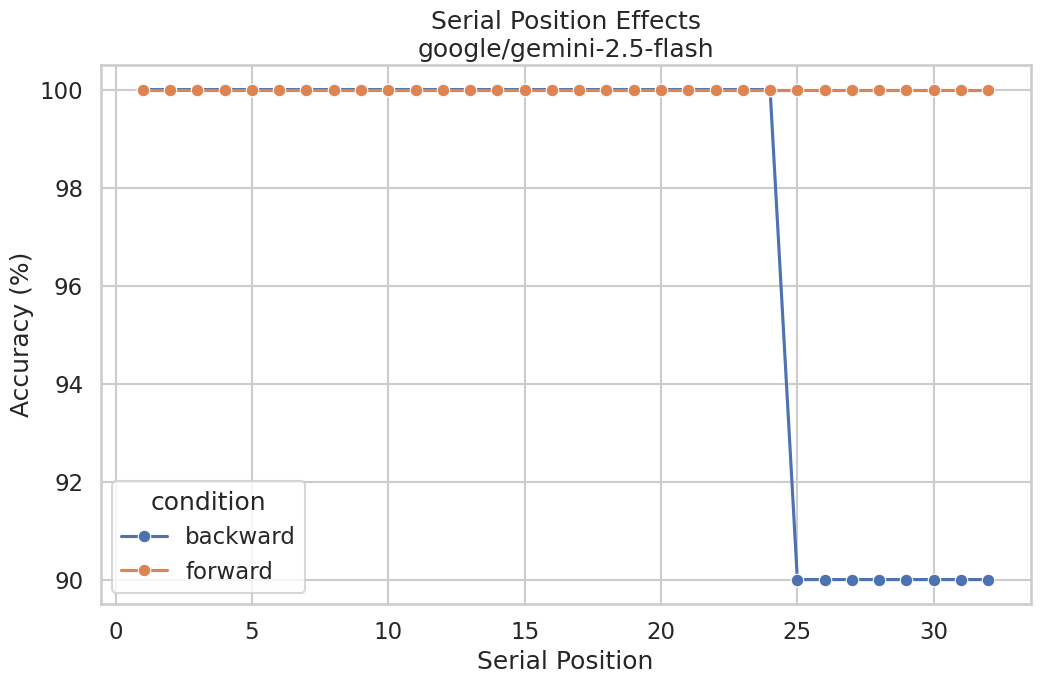


EXPERIMENT COMPLETE

You can now analyze:
- Forward vs backward span
- Capacity thresholds
- Serial-position effects
- Error distributions
- Scaling across models
- Parameter-count effects
- Reasoning vs memory tradeoffs


In [4]:
# ============================================================
# GEMINI / GEMMA DIGIT SPAN CAPACITY EXPERIMENT
# ============================================================
# Google Colab Native LLM Access Version
#
# No API key required.
#
# Uses:
#   from google.colab import ai
#
# Tests:
#   1. Forward digit span
#   2. Backward digit span
#
# Measures:
#   - Exact-match accuracy
#   - Item-level accuracy
#   - Capacity thresholds
#   - Serial-position effects
#
# ============================================================


# =========================
# INSTALL DEPENDENCIES
# =========================
!pip -q install pandas matplotlib seaborn tqdm


# =========================
# IMPORTS
# =========================
import re
import time
import random
from typing import List, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

from google.colab import ai


# =========================
# REPRODUCIBILITY
# =========================
SEED = 1234

random.seed(SEED)
np.random.seed(SEED)


# =========================
# AVAILABLE MODELS
# =========================
print("Available models:")
print(ai.list_models())


# =========================
# MODEL CONFIGURATION
# =========================
# Recommended:
#
# "google/gemini-2.5-flash"
# "google/gemini-2.5-pro"
# "google/gemma-3-1b"
# "google/gemma-3-27b"
#
# You can test multiple models.

MODELS = [
    "google/gemini-2.5-flash",
    # "google/gemini-2.5-pro",
    # "google/gemma-3-1b",
    # "google/gemma-3-27b",
]


# =========================
# EXPERIMENT PARAMETERS
# =========================
SEQUENCE_LENGTHS = [2,4,8,16,32]

TRIALS_PER_LENGTH = 10

DIGITS = list("0123456789")

ALLOW_REPEATED_DIGITS = True

REQUEST_SLEEP = 0.1

CONDITIONS = [
    "forward",
    "backward",
]


# =========================
# PROMPT TEMPLATES
# =========================
FORWARD_PROMPT_TEMPLATE = """
You will be shown a sequence of digits.

Repeat the digits EXACTLY in the SAME ORDER.

Output ONLY the digits separated by spaces.
Do not add explanations or extra text.

Digits:
{digits}
"""


BACKWARD_PROMPT_TEMPLATE = """
You will be shown a sequence of digits.

Repeat the digits in REVERSE ORDER.

Output ONLY the digits separated by spaces.
Do not add explanations or extra text.

Digits:
{digits}
"""


# =========================
# REGEX FOR DIGIT PARSING
# =========================
DIGIT_REGEX = re.compile(r"\d")


# =========================
# UTILITY FUNCTIONS
# =========================
def generate_digit_sequence(length: int,
                            allow_repeats: bool = True) -> List[str]:

    if allow_repeats:
        return [random.choice(DIGITS) for _ in range(length)]

    if length > len(DIGITS):
        raise ValueError("Length exceeds unique digits available")

    return random.sample(DIGITS, length)



def sequence_to_prompt_string(seq: List[str]) -> str:
    return " ".join(seq)



def extract_digits(text: str) -> List[str]:
    return DIGIT_REGEX.findall(text)



def score_trial(predicted: List[str],
                target: List[str]) -> Dict:

    exact_match = predicted == target

    if len(predicted) == len(target):

        item_accuracy = np.mean([
            p == t for p, t in zip(predicted, target)
        ])

    else:

        item_accuracy = 0.0

    return {
        "exact_match": int(exact_match),
        "item_accuracy": float(item_accuracy),
    }


# =========================
# MODEL QUERY FUNCTION
# =========================
def query_model(prompt: str,
                model_name: str,
                max_retries: int = 5) -> str:

    for attempt in range(max_retries):

        try:

            response = ai.generate_text(
                prompt,
                model_name=model_name,
            )

            return str(response).strip()

        except Exception as e:

            wait_time = 2 ** attempt

            print(f"Error: {e}")
            print(f"Retrying in {wait_time} seconds...")

            time.sleep(wait_time)

    return ""


# =========================
# QUICK TEST
# =========================
print("\nRunning quick test...")

test_response = query_model(
    "Repeat backwards: 3 8 1 9",
    MODELS[0],
)

print("Test response:")
print(test_response)


# =========================
# RUN EXPERIMENT
# =========================
all_results = []

for MODEL_NAME in MODELS:

    print("\n================================================")
    print(f"RUNNING MODEL: {MODEL_NAME}")
    print("================================================")

    TOTAL_TRIALS = (
        len(SEQUENCE_LENGTHS)
        * TRIALS_PER_LENGTH
        * len(CONDITIONS)
    )

    trial_counter = 0

    for condition in CONDITIONS:

        print("\n--------------------------------")
        print(f"Condition: {condition}")
        print("--------------------------------")

        for seq_length in tqdm(
            SEQUENCE_LENGTHS,
            desc=f"{MODEL_NAME} | {condition}"
        ):

            for trial_idx in range(TRIALS_PER_LENGTH):

                # ------------------------------------
                # Generate sequence
                # ------------------------------------
                sequence = generate_digit_sequence(
                    seq_length,
                    allow_repeats=ALLOW_REPEATED_DIGITS,
                )

                presented = sequence_to_prompt_string(sequence)

                # ------------------------------------
                # Forward condition
                # ------------------------------------
                if condition == "forward":

                    target = sequence

                    prompt = FORWARD_PROMPT_TEMPLATE.format(
                        digits=presented
                    )

                # ------------------------------------
                # Backward condition
                # ------------------------------------
                else:

                    target = list(reversed(sequence))

                    prompt = BACKWARD_PROMPT_TEMPLATE.format(
                        digits=presented
                    )

                # ------------------------------------
                # Query model
                # ------------------------------------
                raw_response = query_model(
                    prompt,
                    MODEL_NAME,
                )

                # ------------------------------------
                # Parse response
                # ------------------------------------
                predicted = extract_digits(raw_response)

                # ------------------------------------
                # Score
                # ------------------------------------
                scores = score_trial(
                    predicted,
                    target,
                )

                # ------------------------------------
                # Store results
                # ------------------------------------
                all_results.append({
                    "model": MODEL_NAME,
                    "condition": condition,
                    "sequence_length": seq_length,
                    "trial": trial_idx,
                    "presented_sequence": "".join(sequence),
                    "target_sequence": "".join(target),
                    "raw_response": raw_response,
                    "predicted_sequence": "".join(predicted),
                    "prediction_length": len(predicted),
                    **scores,
                })

                trial_counter += 1

                if trial_counter % 25 == 0:

                    print(
                        f"Completed "
                        f"{trial_counter}/{TOTAL_TRIALS}"
                    )

                time.sleep(REQUEST_SLEEP)


# =========================
# CREATE DATAFRAME
# =========================
df = pd.DataFrame(all_results)

print("\nExperiment finished.")
print(df.head())

print("\nData shape:")
print(df.shape)


# =========================
# SAVE RAW RESULTS
# =========================
RAW_RESULTS_FILE = "digit_span_results.csv"

df.to_csv(RAW_RESULTS_FILE, index=False)

print(f"\nSaved raw results to:")
print(RAW_RESULTS_FILE)


# =========================
# AGGREGATE PERFORMANCE
# =========================
summary = (
    df.groupby([
        "model",
        "condition",
        "sequence_length",
    ])
    .agg(
        exact_accuracy=("exact_match", "mean"),
        item_accuracy=("item_accuracy", "mean"),
        n=("exact_match", "size"),
    )
    .reset_index()
)

summary["exact_accuracy_percent"] = (
    summary["exact_accuracy"] * 100
)

summary["item_accuracy_percent"] = (
    summary["item_accuracy"] * 100
)

print("\nSummary:")
print(summary.head())


# =========================
# CAPACITY ESTIMATION
# =========================
capacity_estimates = []

for model_name in MODELS:

    for condition in CONDITIONS:

        subset = summary[
            (summary["model"] == model_name)
            &
            (summary["condition"] == condition)
        ].sort_values("sequence_length")

        passing = subset[
            subset["exact_accuracy"] >= 0.5
        ]

        if len(passing) == 0:
            capacity = None
        else:
            capacity = int(
                passing["sequence_length"].max()
            )

        capacity_estimates.append({
            "model": model_name,
            "condition": condition,
            "capacity_50pct": capacity,
        })

capacity_df = pd.DataFrame(capacity_estimates)

print("\nEstimated capacities:")
print(capacity_df)


# =========================
# SAVE SUMMARY FILES
# =========================
SUMMARY_FILE = "digit_span_summary.csv"
CAPACITY_FILE = "digit_span_capacity.csv"

summary.to_csv(SUMMARY_FILE, index=False)
capacity_df.to_csv(CAPACITY_FILE, index=False)

print(f"\nSaved summary to: {SUMMARY_FILE}")
print(f"Saved capacity estimates to: {CAPACITY_FILE}")


# =========================
# PLOTTING
# =========================
sns.set(
    style="whitegrid",
    context="talk",
)


# ============================================================
# PLOT 1:
# EXACT-MATCH ACCURACY
# ============================================================
for model_name in MODELS:

    subset = summary[
        summary["model"] == model_name
    ]

    plt.figure(figsize=(12, 7))

    sns.lineplot(
        data=subset,
        x="sequence_length",
        y="exact_accuracy_percent",
        hue="condition",
        marker="o",
    )

    plt.xlabel("Sequence Length")
    plt.ylabel("Exact Match Accuracy (%)")

    plt.title(
        f"Digit Span Exact Accuracy\n{model_name}"
    )

    plt.ylim(0, 105)

    plt.show()


# ============================================================
# PLOT 2:
# ITEM-LEVEL ACCURACY
# ============================================================
for model_name in MODELS:

    subset = summary[
        summary["model"] == model_name
    ]

    plt.figure(figsize=(12, 7))

    sns.lineplot(
        data=subset,
        x="sequence_length",
        y="item_accuracy_percent",
        hue="condition",
        marker="o",
    )

    plt.xlabel("Sequence Length")
    plt.ylabel("Item-Level Accuracy (%)")

    plt.title(
        f"Digit Span Item Accuracy\n{model_name}"
    )

    plt.ylim(0, 105)

    plt.show()


# =========================
# SERIAL POSITION ANALYSIS
# =========================
position_results = []

for _, row in df.iterrows():

    target = list(row["target_sequence"])
    pred = list(row["predicted_sequence"])

    max_len = min(len(target), len(pred))

    for pos in range(max_len):

        position_results.append({
            "model": row["model"],
            "condition": row["condition"],
            "sequence_length": row["sequence_length"],
            "position": pos + 1,
            "correct": int(
                target[pos] == pred[pos]
            )
        })

position_df = pd.DataFrame(position_results)


# ============================================================
# SERIAL POSITION PLOTS
# ============================================================
for model_name in MODELS:

    subset = position_df[
        position_df["model"] == model_name
    ]

    pos_summary = (
        subset
        .groupby([
            "condition",
            "position",
        ])["correct"]
        .mean()
        .reset_index()
    )

    pos_summary["correct"] *= 100

    plt.figure(figsize=(12, 7))

    sns.lineplot(
        data=pos_summary,
        x="position",
        y="correct",
        hue="condition",
        marker="o",
    )

    plt.xlabel("Serial Position")
    plt.ylabel("Accuracy (%)")

    plt.title(
        f"Serial Position Effects\n{model_name}"
    )

    plt.show()


# =========================
# DONE
# =========================
print("\n================================================")
print("EXPERIMENT COMPLETE")
print("================================================")

print("\nYou can now analyze:")

print("- Forward vs backward span")
print("- Capacity thresholds")
print("- Serial-position effects")
print("- Error distributions")
print("- Scaling across models")
print("- Parameter-count effects")
print("- Reasoning vs memory tradeoffs")